# Fig S9B -- inverse-problem sampling-noise model comparison

CIPHER's posterior inverse problem ranks every gene as the likely driver of each
perturbation's observed mean-shift `dx`, under two sampling-noise models in the
control-covariance eigenbasis: a per-eigenmode diagonal **CLT / fullH_diag** noise
(`h = lambda/n0 + diag(V^T Sigma_pert V)/n_pert`) versus a trace-matched **isotropic**
scalar noise. Per dataset it filters genes/perturbations, eigendecomposes the raw-count
control covariance, fits an empirical-Bayes prior `tau2` (plateau rule) separately per
noise model, and scores every perturbation (target rank percentile, top-K recovery,
parametric-null p-value, gene-level top-K false-positive rate vs control-variance
percentile). The deliverable is Fig S9B: panel **B** (top-K target recovery) and panel
**D** (variance-driven false positives), rendered by `make_two_panel_bd` from the
aggregate CSVs.

`run_inverse_from_precomputed` is the canonical compute path (reads the precomputed
Sigma/dx tree, the same tree Fig S7 uses). `run_inverse_from_raw` is the from-raw-h5ad
fallback used when the precompute tree lacks the extra fields (`n_control`,
`pert_eigvar_true` / `var_pert`) this analysis needs. Run one compute cell, then
`make_two_panel_bd`.

In [1]:
import os, sys
import importlib as _il
try:
    _std_tqdm = _il.import_module('tqdm.std').tqdm
    for _m in ('tqdm', 'tqdm.auto', 'tqdm.notebook', 'tqdm.autonotebook'):
        try: _il.import_module(_m).tqdm = _std_tqdm
        except Exception: pass
except Exception:
    pass
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "suppl" else os.getcwd())

from src.run_figS9B import *
from src.logutil import route_logs
DATA_DIR = os.environ["CIPHER_DATA_DIR"]
SUPPL = os.path.join(DATA_DIR, "suppl")
OUTDIR = os.environ.get("SUPPL_OUT", "resources/repro/figS9B")
os.makedirs(OUTDIR, exist_ok=True)
route_logs("figS9B_inverse_noise_model")
import src.run_figS9B as R
R.__dict__.update({k: v for k, v in globals().items() if k.isupper() or k in ("DATA_DIR","SUPPL","OUTDIR")})

[logs] verbose output -> ../../resources/repro/figS9B/logs/figS9B_inverse_noise_model.log


## Canonical compute: from the precomputed Sigma/dx tree

Scores every `*__mean_ge_1p0` dataset folder under
`$SUPPL/precomputed_FULL_COV_FAST_FULLLOAD_CHUNKED`, writing per-dataset and
`ALL_DATASETS__*` per-perturbation / gene false-positive CSVs plus the summary JSON and
the four-panel comparison figure directly under `OUTDIR`. Heavy (full dense
eigendecomposition per dataset); run under SLURM.

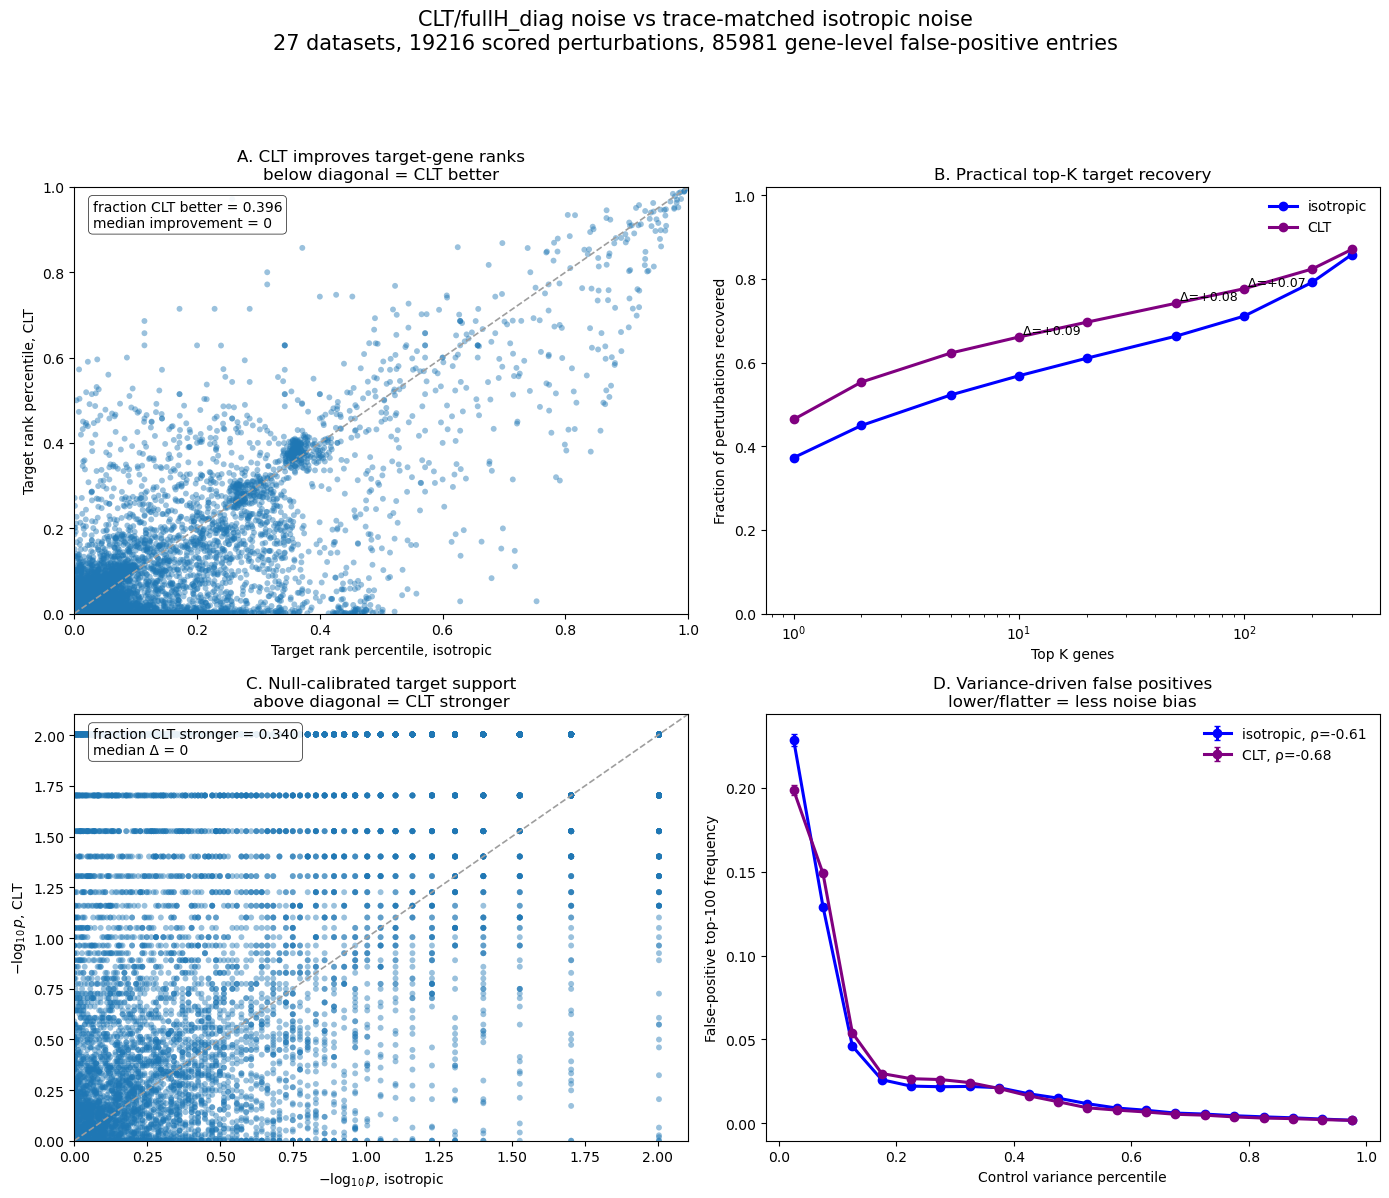

In [2]:
R.run_inverse_from_precomputed()

## Fallback compute: from the raw h5ads

Recomputes control and per-perturbation covariances directly from the raw counts in the
dataset h5ads (via `cipher.compute_covariance`) and produces the same aggregate CSVs and
figure. Use this if the precompute tree is missing `n_control` or the per-perturbation
projected variance the precomputed path needs. Run only one of the two compute cells.

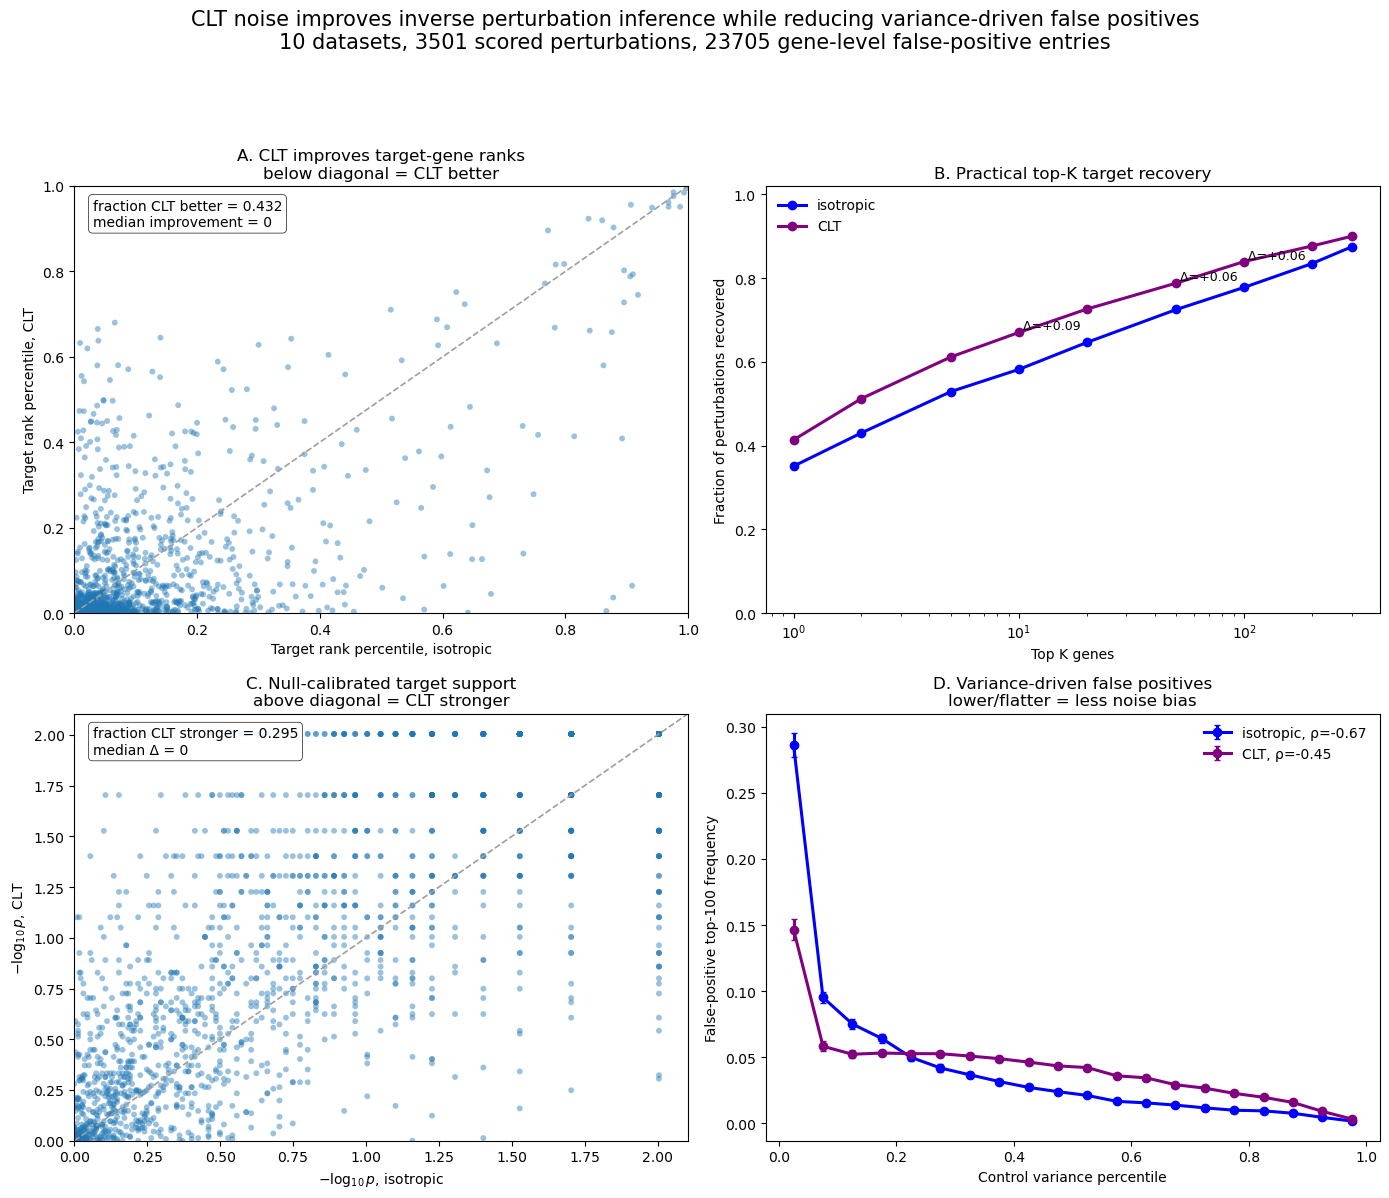

In [3]:
R.run_inverse_from_raw()

## Fig S9B: panels B and D

Reads the `ALL_DATASETS__*` CSVs from `OUTDIR` (written by whichever compute cell you ran
above) and renders the two-panel figure: top-K target recovery (B) and variance-dependent
false positives (D).

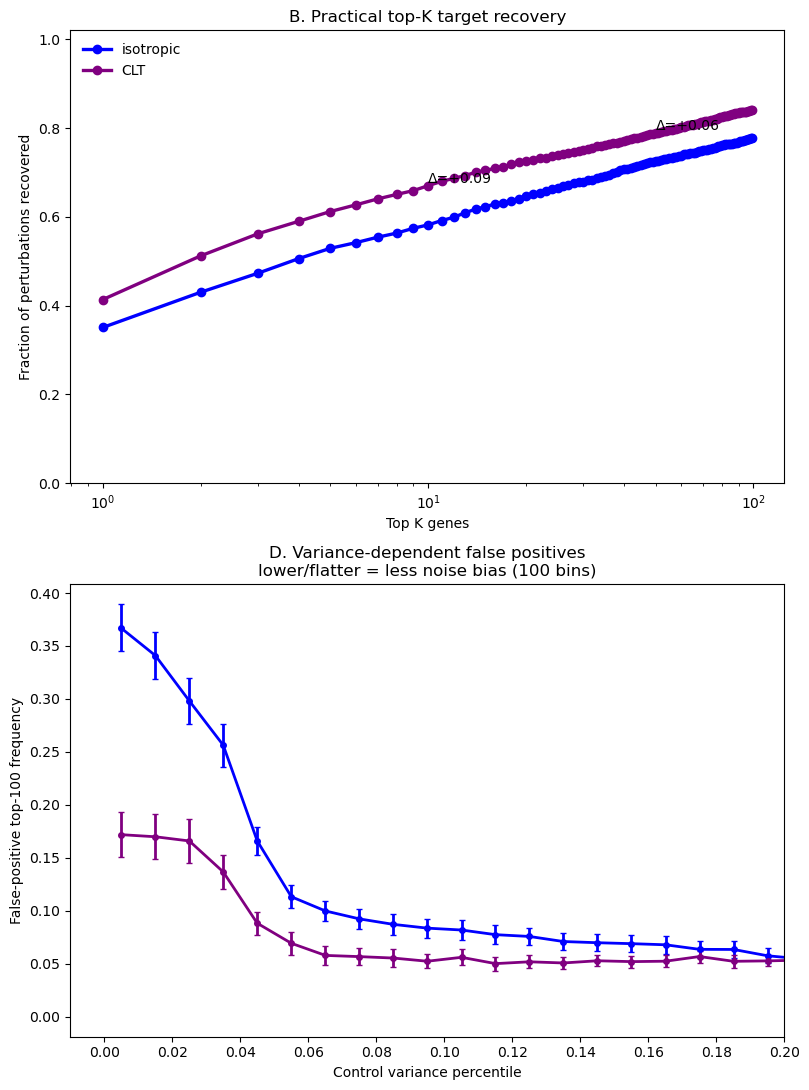

In [4]:
R.make_two_panel_bd()